# 🧠 Görüntü İşleme — İleri Seviye (CIFAR-10)

> **Ön koşul:** Temel görüntü işleme notebook'u tamamlanmış olmalı.
> Bu notebook bir üst katmana çıkar: **veri artırma, PCA, t-SNE, SVM, MLP, CNN.**

---

## 📚 Bu Notebook'ta Ne Öğreneceksiniz?

| # | Bölüm | Zorluk |
|---|-------|--------|
| 1 | Veri Seti Yükleme ve Hazırlık | ⭐ |
| 2 | Veri Artırma (Data Augmentation) | ⭐⭐ |
| 3 | PCA ile Boyut İndirgeme | ⭐⭐ |
| 4 | t-SNE ile Özellik Uzayı Keşfi | ⭐⭐⭐ |
| 5 | SVM ile Sınıflandırma | ⭐⭐ |
| 6 | MLP ile Sınıflandırma | ⭐⭐⭐ |
| 7 | CNN — Sıfırdan İleri Yayılım | ⭐⭐⭐⭐ |

> **Veri Seti:** CIFAR-10 (Kaggle CIFAR-10)
> - 50,000 eğitim + 10,000 test görüntüsü
> - 32×32 piksel, renkli (3 kanal — RGB)
> - 10 sınıf: Uçak, Araba, Kuş, Kedi, Geyik, Köpek, Kurbağa, At, Gemi, Kamyon


## 🔧 Bolum 0 — Kaggle API Kurulumu ve Veri Indirme

Kaggle'dan CIFAR-10 veri setini otomatik indirmek icin API kimlik bilgilerinizi girin.

> **Nasil alinir?**
> 1. https://www.kaggle.com adresine gidin ve giris yapin
> 2. Sag ustteki profil resminize tiklayin -> "Settings"
> 3. "API" bolumunden "Create New Token" butonuna tiklayin
> 4. Indirilen `kaggle.json` dosyasindaki icerigi kullanin:
>    - **Username**: `kullaniciAdi` bolumu
>    - **Key**: `apiKey` bolumu

> **Not:** CIFAR-10 veri seti `torchvision` kutuphanesi ile de otomatik indirilir.
> Eger torchvision varsa, Kaggle API'ye ihtiyac yoktur.

In [1]:
import getpass
import os
import json
import zipfile

# Kaggle API kimlik bilgilerini sor
print("=== Kaggle API Kimlik Bilgileri ===")
print("https://www.kaggle.com -> Settings -> API -> Create New Token")
print()

kullanici_adi = input("Kaggle kullanici adinizi girin: ")
api_key = getpass.getpass("Kaggle API key girin (gizli olarak girilecek): ")

# kaggle.json dosyasini olustur
kaggle_dir = os.path.expanduser('~/.kaggle')
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_creds = {"username": kullanici_adi, "key": api_key}
with open(os.path.join(kaggle_dir, 'kaggle.json'), 'w') as f:
    json.dump(kaggle_creds, f)

print("\nKaggle API basariyla ayarlandi!")

=== Kaggle API Kimlik Bilgileri ===
https://www.kaggle.com -> Settings -> API -> Create New Token

Kaggle kullanici adinizi girin: https://www.kaggle.com/gamzedrn
Kaggle API key girin (gizli olarak girilecek): ··········

Kaggle API basariyla ayarlandi!


In [2]:
# kaggle kutuphanesini kur
!pip install kaggle -q

# CIFAR-10 veri setini indir
!kaggle competitions download -c cifar-10 -p ./data/cifar10 --force

# Zip dosyasini cikar
zip_path = './data/cifar10/cifar-10.zip'
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('./data/cifar10')
    print("CIFAR-10 veri seti basariyla indirildi!")
    print(f"Dosyalar: {os.listdir('./data/cifar10')}")
else:
    print("Uyari: Zip dosyasi bulunamadi.")
    print("Alternatif: torchvision ile otomatik indirilecek.")

401 Client Error: Unauthorized for url: https://api.kaggle.com/v1/competitions.CompetitionApiService/DownloadDataFiles
Uyari: Zip dosyasi bulunamadi.
Alternatif: torchvision ile otomatik indirilecek.


## ⚙️ Kurulum

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import os
import cv2
from PIL import Image

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
print("Kurulum tamamlandi!")

Kurulum tamamlandi!


## 📂 Bölüm 1 — CIFAR-10 Veri Setini Yükle

In [4]:
# CIFAR-10 sinif isimleri
SINIF_ISIMLERI = ['ucak', 'araba', 'kus', 'kedi', 'geyik',
                   'kopek', 'kurbağa', 'at', 'gemi', 'kamyon']

# Yontem 1: torchvision ile yukle (otomatik indirir)
try:
    import torch
    import torchvision
    import torchvision.transforms as transforms

    transform = transforms.Compose([transforms.ToTensor()])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                            download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                           download=True, transform=transform)

    # Tensörleri numpy dizisine çevir
    X_train = trainset.data.transpose(0, 3, 1, 2).reshape(len(trainset), -1).astype(np.float32) / 255.0
    y_train = np.array(trainset.targets)
    X_test = testset.data.transpose(0, 3, 1, 2).reshape(len(testset), -1).astype(np.float32) / 255.0
    y_test = np.array(testset.targets)

    X_all = np.vstack([X_train, X_test])
    y_all = np.concatenate([y_train, y_test])
    X_images = X_all.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)  # (N, 32, 32, 3)

    print(f"Yontem 1: torchvision ile yuklendi")
except:
    # Yontem 2: Kaggle'dan indirilen train/ klasöründen yukle
    print("torchvision bulunamadi, train/ klasöründen yukleniyor...")
    train_dir = 'train'
    X_list, y_list = [], []
    for sinif_idx, sinif_adi in enumerate(SINIF_ISIMLERI):
        klasor = os.path.join(train_dir, sinif_adi)
        if os.path.exists(klasor):
            for dosya in os.listdir(klasor)[:500]:  # Her siniftan 500 ornek
                img = cv2.imread(os.path.join(klasor, dosya))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (32, 32))
                X_list.append(img.flatten() / 255.0)
                y_list.append(sinif_idx)
    X_all = np.array(X_list)
    y_all = np.array(y_list)
    X_images = X_all.reshape(-1, 32, 32, 3)
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

# Egitim/test bolmesi (eger yuksekten yuklendiyse)
if 'X_train' not in dir() or len(X_train) < 1000:
    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
    )

# Gorsellestirme icin ornek sec
X_display = X_images[:len(X_all)]

print(f"Egitim: {X_train.shape[0]} ornek")
print(f"Test: {X_test.shape[0]} ornek")
print(f"Ozellik boyutu: {X_train.shape[1]}")
print(f"Sinif sayisi: {len(np.unique(y_all))}")

100%|██████████| 170M/170M [1:02:04<00:00, 45.8kB/s]


Yontem 1: torchvision ile yuklendi
Egitim: 50000 ornek
Test: 10000 ornek
Ozellik boyutu: 3072
Sinif sayisi: 10


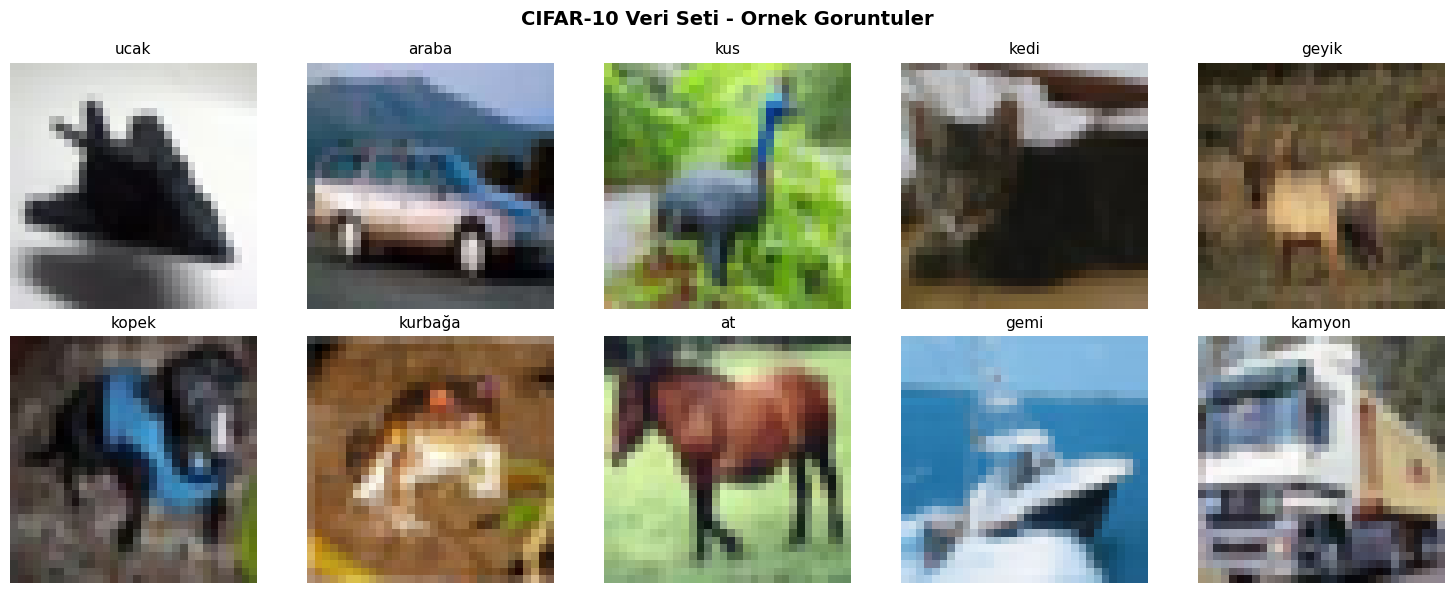

In [5]:
# Ornek goruntuleri gorsellestir
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    idx = np.where(y_all == i)[0][0]
    img = X_images[idx]
    ax.imshow(img)
    ax.set_title(f"{SINIF_ISIMLERI[i]}", fontsize=11)
    ax.axis('off')

plt.suptitle("CIFAR-10 Veri Seti - Ornek Goruntuler", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 🔀 Bölüm 2 — Veri Artırma (Data Augmentation)

**Problem:** Gerçek projelerde etiketli veri az olur. Modeli overfit'ten korumak icin
mevcut goruntuleri **donusturerek** yapay yeni ornekler uretilir.

**Neden ise yarar?** Model ayni nesnenin farkli aci/parlaklik/gurultu versiyonlarini gorunce
gercek dunya varyasyonlarini ogrenir.

```
Orijinal -> Dondur -> Kaydir -> Olcekle -> Gurultu ekle -> Ayna -> Parlaklik degistir
```

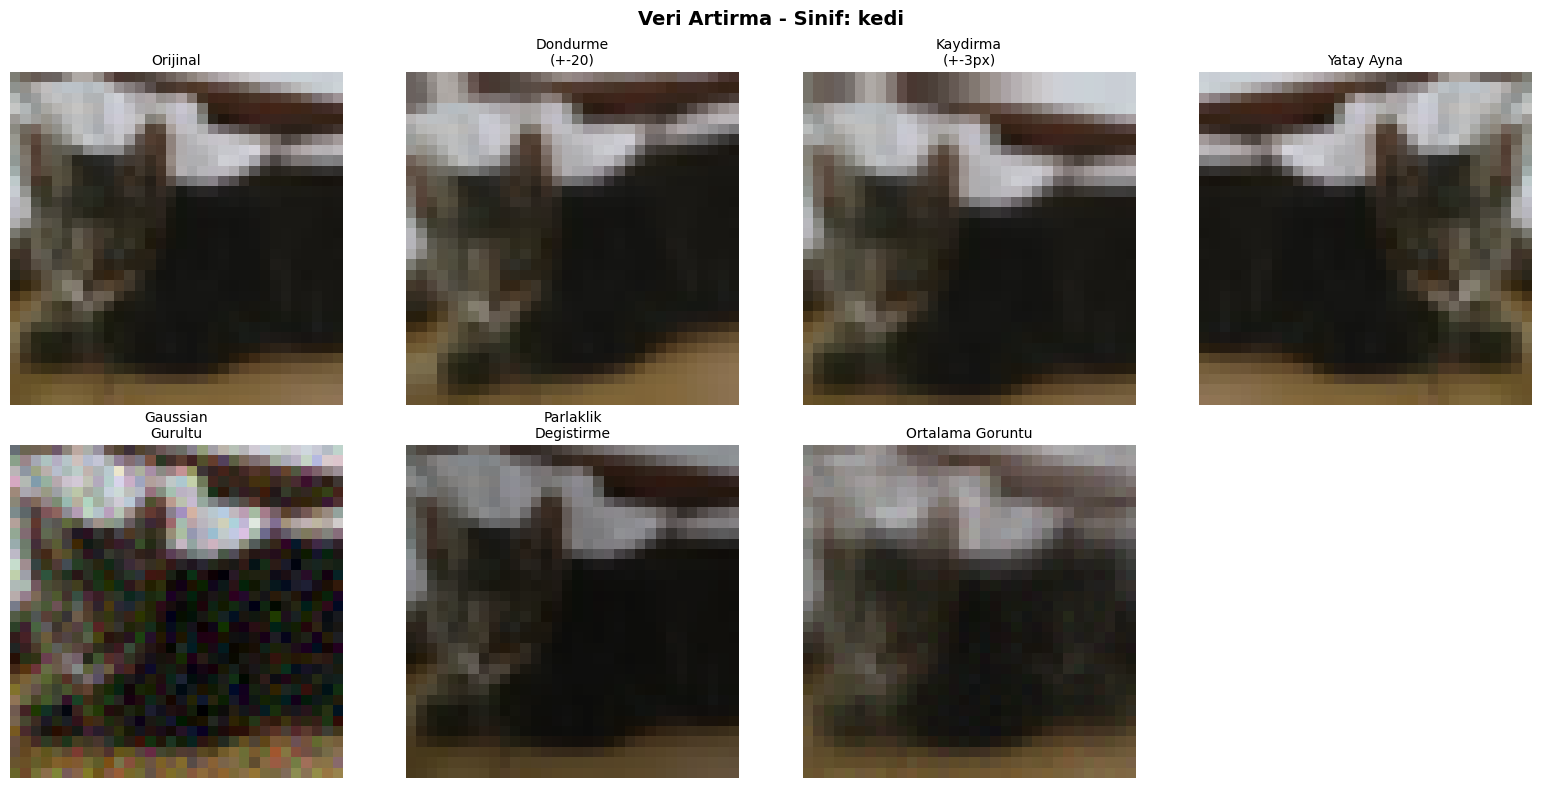

In [6]:
def augment_image(img_2d, seed=None):
    """Tek bir 32x32 goruntuye rastgele augmentation uygula."""
    rng = np.random.default_rng(seed)
    img_uint8 = (img_2d * 255).astype(np.uint8)

    results = {}
    results['original'] = img_2d.copy()

    # 1. Dondurme (Rotation)
    angle = rng.uniform(-20, 20)
    h, w = img_uint8.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    rotated = cv2.warpAffine(img_uint8, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    results['rotation'] = rotated.astype(float) / 255

    # 2. Kaydirma (Translation)
    tx = rng.uniform(-3, 3)
    ty = rng.uniform(-3, 3)
    M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
    shifted = cv2.warpAffine(img_uint8, M_trans, (w, h), borderMode=cv2.BORDER_REPLICATE)
    results['translation'] = shifted.astype(float) / 255

    # 3. Yatay Ayna (Horizontal Flip)
    flipped = np.fliplr(img_uint8)
    results['flip'] = flipped.astype(float) / 255

    # 4. Gaussian Gurultu
    sigma = rng.uniform(5, 15)
    noise = rng.normal(0, sigma, img_uint8.shape).astype(np.int16)
    noisy = np.clip(img_uint8.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    results['noise'] = noisy.astype(float) / 255

    # 5. Parlaklik Degistirme
    factor = rng.uniform(0.7, 1.4)
    bright = np.clip(img_uint8.astype(float) * factor, 0, 255).astype(np.uint8)
    results['brightness'] = bright.astype(float) / 255

    return results

# Ornek uygulama
ornek_idx = np.where(y_all == 3)[0][0]  # Kedi ornegi
ornek_img = X_images[ornek_idx]
aug_results = augment_image(ornek_img, seed=42)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

titles = ['Orijinal', 'Dondurme\n(+-20)', 'Kaydirma\n(+-3px)',
          'Yatay Ayna', 'Gaussian\nGurultu', 'Parlaklik\nDegistirme',
          'Toplam', '']

for i, (key, img) in enumerate(aug_results.items()):
    axes[i].imshow(img)
    axes[i].set_title(titles[i], fontsize=10)
    axes[i].axis('off')

axes[6].imshow(np.mean([v for v in aug_results.values()], axis=0))
axes[6].set_title('Ortalama Goruntu', fontsize=10)
axes[6].axis('off')
axes[7].axis('off')

plt.suptitle(f"Veri Artirma - Sinif: {SINIF_ISIMLERI[y_all[ornek_idx]]}",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 📉 Bölüm 3 — PCA ile Boyut İndirgeme

**Problem:** 3072 ozellik (32x32x3) -> gorsellestirme imkansiz.
**PCA (Principal Component Analysis):** Veriyi en fazla varyansi koruyan eksenlere yansitir.

```
3072 boyut  -> PCA -> 2-3 boyut   (gorsellestirme icin)
3072 boyut  -> PCA -> 50-100 boyut (siniflandirma icin, bilgi kaybi az)
```

%90 varyans icin gerekli bilesen: 99
%95 varyans icin gerekli bilesen: 217
%99 varyans icin gerekli bilesen: 658
Orijinal boyut: 3072  ->  Sikistirma orani (%90): 31.0x


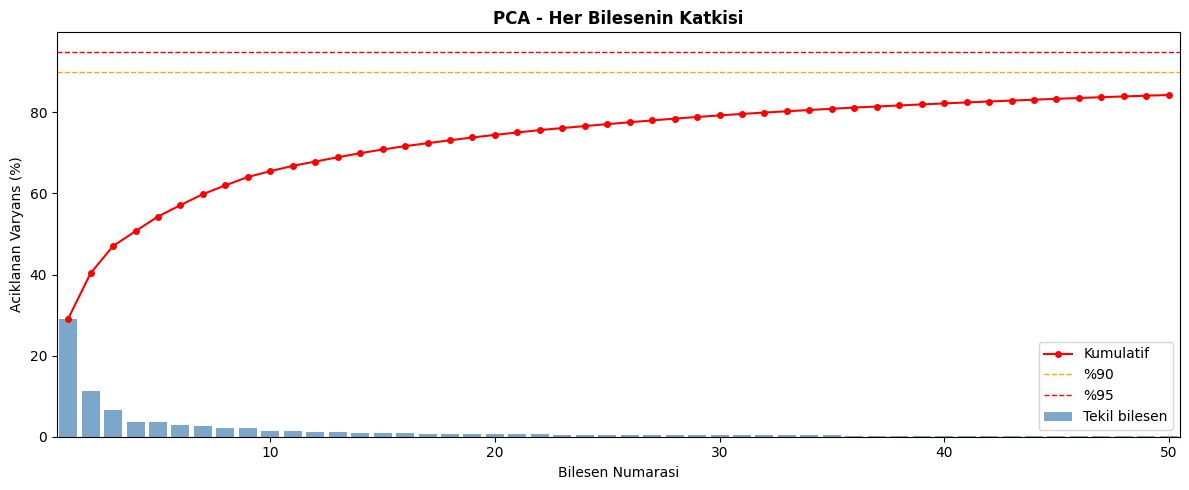

In [7]:
# PCA ile boyut indirgeme
pca_full = PCA()
pca_full.fit(X_train)

# Kumulatif aciklanan varyans
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n90 = np.searchsorted(cumvar, 0.90) + 1
n95 = np.searchsorted(cumvar, 0.95) + 1
n99 = np.searchsorted(cumvar, 0.99) + 1

print(f"%90 varyans icin gerekli bilesen: {n90}")
print(f"%95 varyans icin gerekli bilesen: {n95}")
print(f"%99 varyans icin gerekli bilesen: {n99}")
print(f"Orijinal boyut: {X_train.shape[1]}  ->  Sikistirma orani (%90): {X_train.shape[1]/n90:.1f}x")

# Varyans grafigi
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(1, 51), pca_full.explained_variance_ratio_[:50]*100,
       color='steelblue', alpha=0.7, label='Tekil bilesen')
ax.plot(range(1, 51), cumvar[:50]*100,
        'ro-', markersize=4, linewidth=1.5, label='Kumulatif')
ax.axhline(y=90, color='orange', linestyle='--', linewidth=1, label='%90')
ax.axhline(y=95, color='red', linestyle='--', linewidth=1, label='%95')
ax.set_xlabel("Bilesen Numarasi")
ax.set_ylabel("Aciklanan Varyans (%)")
ax.set_title("PCA - Her Bilesenin Katkisi", fontweight='bold')
ax.legend()
ax.set_xlim(0.5, 50.5)
plt.tight_layout()
plt.show()

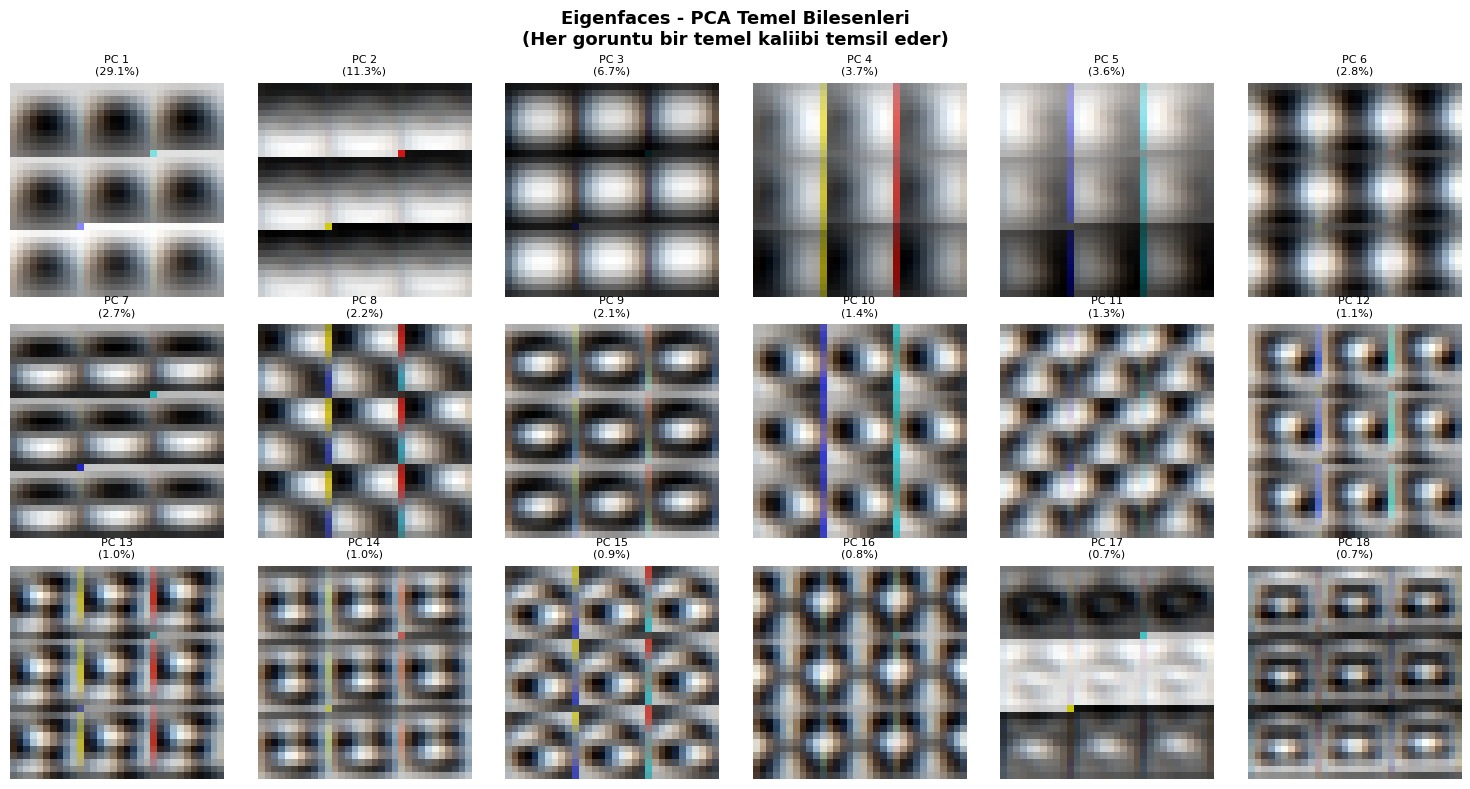

In [8]:
# Eigenfaces (PCA bilesenlerini goruntule)
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

for i, ax in enumerate(axes.flat):
    if i < 18:
        eigenimg = pca_full.components_[i].reshape(32, 32, 3)
        eigenimg = (eigenimg - eigenimg.min()) / (eigenimg.max() - eigenimg.min())
        ax.imshow(eigenimg)
        ax.set_title(f"PC {i+1}\n({pca_full.explained_variance_ratio_[i]*100:.1f}%)",
                     fontsize=8)
    ax.axis('off')

plt.suptitle("Eigenfaces - PCA Temel Bilesenleri\n(Her goruntu bir temel kaliibi temsil eder)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 🌌 Bölüm 4 — t-SNE ile Özellik Uzayı Keşfi

**t-SNE (t-distributed Stochastic Neighbor Embedding):**
Yuksek boyutlu veriyi 2D'ye indirger; benzer ornekler yakin, farklilar uzak olur.

> PCA lineerdir - t-SNE **non-lineer**. Kume yapisini cok daha iyi ortaya cikarir.

Adim 1: PCA ile 50 boyuta indir...
  PCA sonrasi: (50000, 50)
Adim 2: t-SNE ile 2 boyuta indir (bu biraz surer)...
  t-SNE sonrasi: (50000, 2)


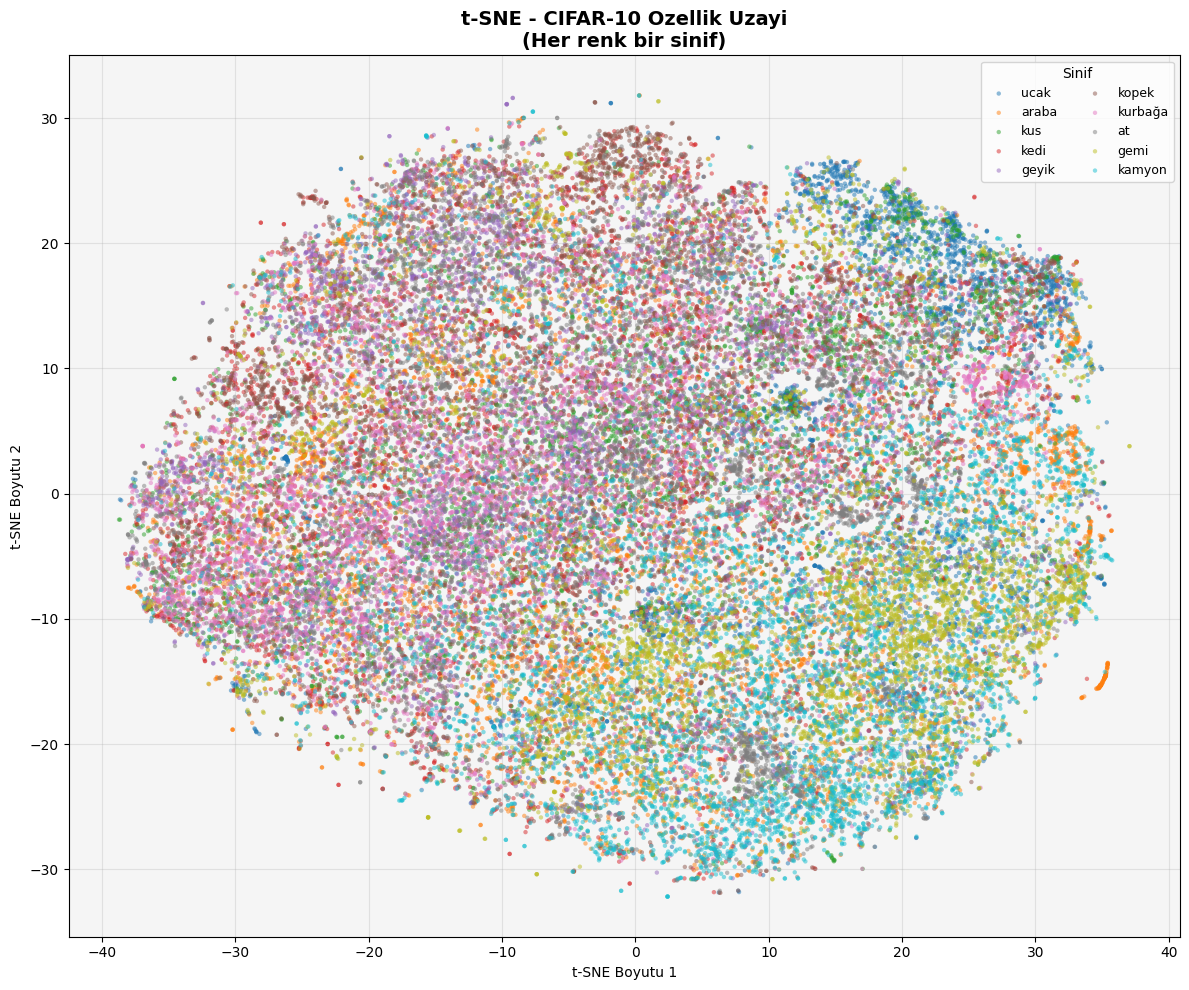


t-SNE'de: Birbirinden ayrusan kumeler = model kolayca ayirt edebilir demektir.


In [9]:
# PCA ile 50 boyuta indir, sonra t-SNE ile 2 boyuta
print("Adim 1: PCA ile 50 boyuta indir...")
pca50 = PCA(n_components=50, random_state=42)
X_pca50 = pca50.fit_transform(X_train)
print(f"  PCA sonrasi: {X_pca50.shape}")

print("Adim 2: t-SNE ile 2 boyuta indir (bu biraz surer)...")
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=500,
    random_state=42,
    learning_rate='auto',
    init='pca'
)
X_tsne = tsne.fit_transform(X_pca50)
print(f"  t-SNE sonrasi: {X_tsne.shape}")

# Gorsellestir
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.tab10(np.linspace(0, 1, 10))

for sinif in range(10):
    mask = y_train == sinif
    ax.scatter(
        X_tsne[mask, 0],
        X_tsne[mask, 1],
        c=[colors[sinif]],
        label=SINIF_ISIMLERI[sinif],
        alpha=0.5,
        s=10,
        edgecolors='none'
    )

ax.set_title("t-SNE - CIFAR-10 Ozellik Uzayi\n(Her renk bir sinif)",
             fontsize=14, fontweight='bold')
ax.legend(title="Sinif", ncol=2, fontsize=9)
ax.set_xlabel("t-SNE Boyutu 1")
ax.set_ylabel("t-SNE Boyutu 2")
ax.set_facecolor('#f5f5f5')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nt-SNE'de: Birbirinden ayrusan kumeler = model kolayca ayirt edebilir demektir.")

## 🎯 Bölüm 5 — SVM ile Sınıflandırma

In [10]:
# PCA ile boyut indirgeme (SVM icin)
pca_svm = PCA(n_components=50, random_state=42)
X_train_pca = pca_svm.fit_transform(X_train)
X_test_pca = pca_svm.transform(X_test)

# Normalizasyon
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_pca)
X_test_sc = scaler.transform(X_test_pca)

# SVM egitimi
print("SVM egitiliyor...")
svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_sc, y_train)

# Tahmin
y_pred_svm = svm.predict(X_test_sc)
acc_svm = accuracy_score(y_test, y_pred_svm)

print(f"\nSVM Dogruluk: {acc_svm*100:.2f}%")
print("\nSiniflandirma Raporu:")
print(classification_report(y_test, y_pred_svm, target_names=SINIF_ISIMLERI))

SVM egitiliyor...

SVM Dogruluk: 53.85%

Siniflandirma Raporu:
              precision    recall  f1-score   support

        ucak       0.57      0.64      0.60      1000
       araba       0.60      0.66      0.63      1000
         kus       0.42      0.41      0.41      1000
        kedi       0.35      0.38      0.36      1000
       geyik       0.50      0.48      0.49      1000
       kopek       0.48      0.44      0.46      1000
     kurbağa       0.58      0.59      0.59      1000
          at       0.64      0.58      0.61      1000
        gemi       0.67      0.64      0.66      1000
      kamyon       0.58      0.56      0.57      1000

    accuracy                           0.54     10000
   macro avg       0.54      0.54      0.54     10000
weighted avg       0.54      0.54      0.54     10000



## 🧠 Bölüm 6 — MLP ile Sınıflandırma

In [11]:
# MLP egitimi
print("MLP egitiliyor...")
mlp = MLPClassifier(
    hidden_layer_sizes=(512, 256, 128),
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
mlp.fit(X_train_sc, y_train)

# Tahmin
y_pred_mlp = mlp.predict(X_test_sc)
acc_mlp = accuracy_score(y_test, y_pred_mlp)

print(f"\nMLP Dogruluk: {acc_mlp*100:.2f}%")
print("\nSiniflandirma Raporu:")
print(classification_report(y_test, y_pred_mlp, target_names=SINIF_ISIMLERI))

MLP egitiliyor...

MLP Dogruluk: 51.67%

Siniflandirma Raporu:
              precision    recall  f1-score   support

        ucak       0.52      0.70      0.60      1000
       araba       0.56      0.72      0.63      1000
         kus       0.39      0.41      0.40      1000
        kedi       0.36      0.28      0.31      1000
       geyik       0.48      0.36      0.42      1000
       kopek       0.47      0.41      0.44      1000
     kurbağa       0.52      0.63      0.57      1000
          at       0.59      0.59      0.59      1000
        gemi       0.65      0.60      0.63      1000
      kamyon       0.60      0.46      0.52      1000

    accuracy                           0.52     10000
   macro avg       0.51      0.52      0.51     10000
weighted avg       0.51      0.52      0.51     10000



## 🔬 Bölüm 7 — CNN — Sıfırdan NumPy ile

CNN'in kalbi: **konvolusyon islemi.** Bir kernel goruntu uzerinde kaydirilir,
her konumda element-wise carpim + toplam yapilir.

```
Output[i,j] = Sigma Sigma Input[i+m, j+n] x Kernel[m, n]
```

Bu bolumde PyTorch/TF kullanmadan, **saf NumPy** ile konvolusyon yazacagiz.

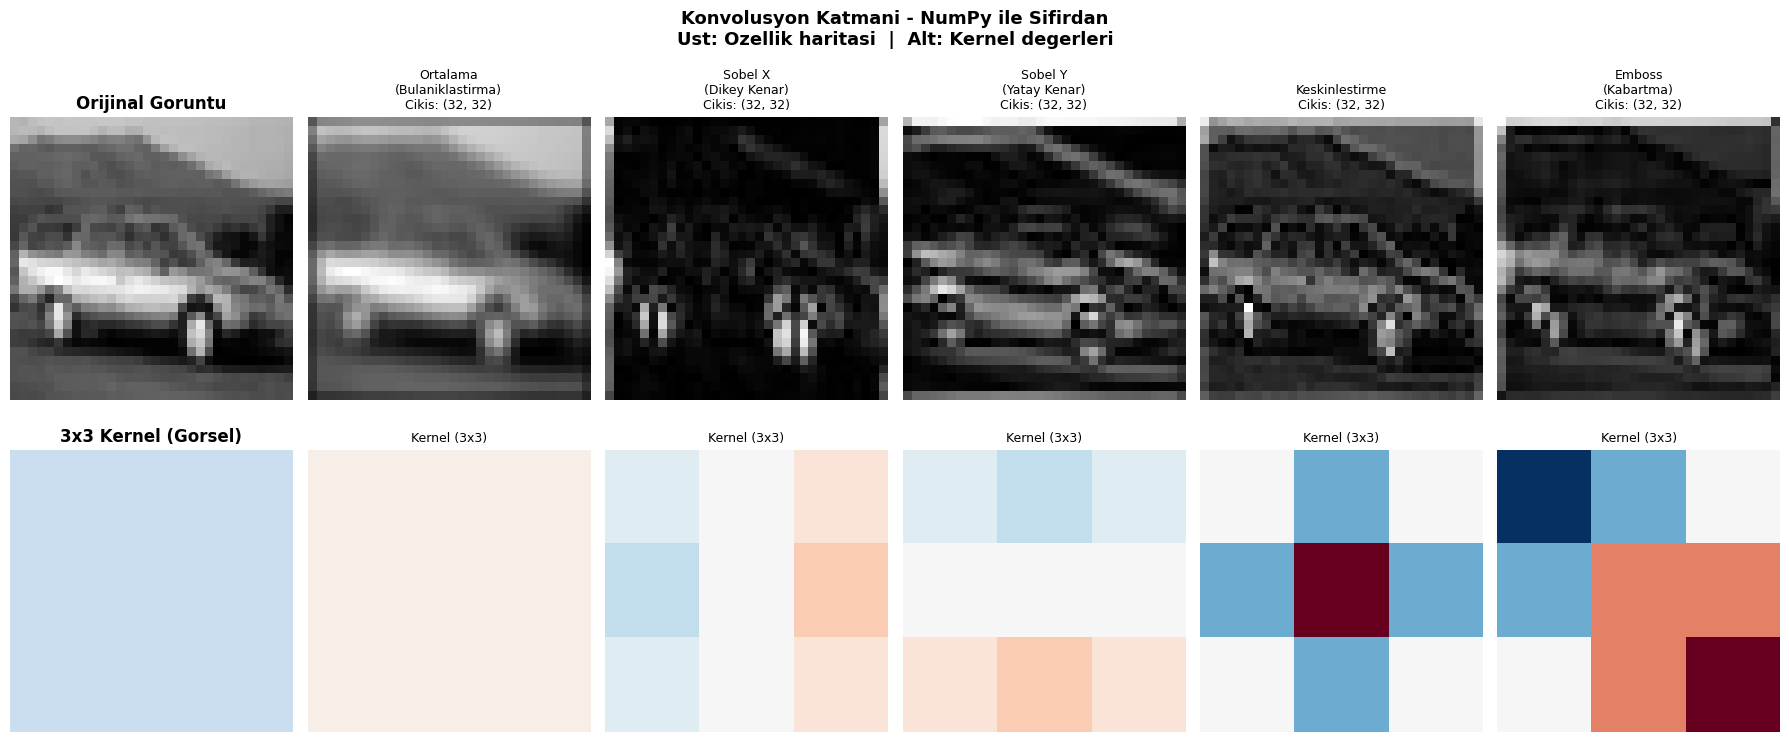

In [12]:
def conv2d_numpy(image, kernel, stride=1, padding=0):
    """2D Konvolusyon - NumPy ile sifirdan implementasyon."""
    H, W = image.shape[:2]
    kH, kW = kernel.shape

    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)),
                       mode='constant', constant_values=0)
        H, W = image.shape

    H_out = (H - kH) // stride + 1
    W_out = (W - kW) // stride + 1
    output = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            patch = image[i*stride:i*stride+kH, j*stride:j*stride+kW]
            output[i, j] = np.sum(patch * kernel)

    return output

# Test goruntusu
ornek_idx = np.where(y_all == 1)[0][0]  # Araba
test_img = X_images[ornek_idx]
test_gray = cv2.cvtColor((test_img * 255).astype(np.uint8), cv2.COLOR_RGB2GRAY).astype(float)

# Farkli kernel'lari test et
kernels = {
    'Ortalama\n(Bulaniklastirma)': np.ones((3,3)) / 9,
    'Sobel X\n(Dikey Kenar)':      np.array([[-1,0,1], [-2,0,2], [-1,0,1]]) / 4.0,
    'Sobel Y\n(Yatay Kenar)':      np.array([[-1,-2,-1], [0,0,0], [1,2,1]]) / 4.0,
    'Keskinlestirme':              np.array([[0,-1,0], [-1,5,-1], [0,-1,0]]),
    'Emboss\n(Kabartma)':          np.array([[-2,-1,0], [-1,1,1], [0,1,2]]),
}

fig, axes = plt.subplots(2, len(kernels)+1, figsize=(18, 8))

axes[0,0].imshow(test_gray, cmap='gray')
axes[0,0].set_title("Orijinal Goruntu", fontweight='bold')
axes[0,0].axis('off')

for col, (name, kernel) in enumerate(kernels.items(), start=1):
    result = conv2d_numpy(test_gray, kernel, padding=1)
    display = np.abs(result)
    display = (display - display.min()) / (display.max() - display.min() + 1e-8) * 255

    axes[0, col].imshow(display.astype(np.uint8), cmap='gray')
    axes[0, col].set_title(f"{name}\nCikis: {result.shape}", fontsize=9)
    axes[0, col].axis('off')

    axes[1, col].imshow(kernel, cmap='RdBu_r', vmin=-2, vmax=2)
    axes[1, col].set_title(f"Kernel ({kernel.shape[0]}x{kernel.shape[1]})", fontsize=9)
    axes[1, col].axis('off')

axes[1,0].imshow(np.ones((3,3))/9, cmap='Blues', vmin=0, vmax=0.5)
axes[1,0].set_title("3x3 Kernel (Gorsel)", fontweight='bold')
axes[1,0].axis('off')

plt.suptitle("Konvolusyon Katmani - NumPy ile Sifirdan\nUst: Ozellik haritasi  |  Alt: Kernel degerleri",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()